In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Pure matplotlib display (no cv2 display or color conversion)
def show(img, title=None, cmap=None):
    plt.figure(figsize=(6,4))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(img)  # assume already RGB
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

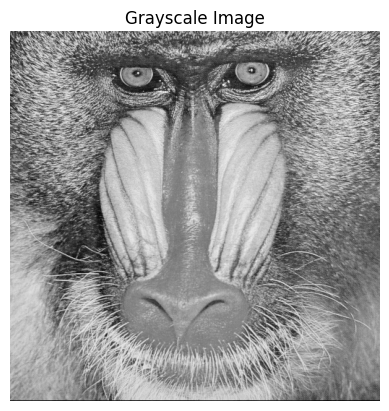

In [7]:
image_data = cv2.imread("dataset/baboon.png", 0)

plt.imshow(image_data, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [8]:
image_data.shape

(512, 512)

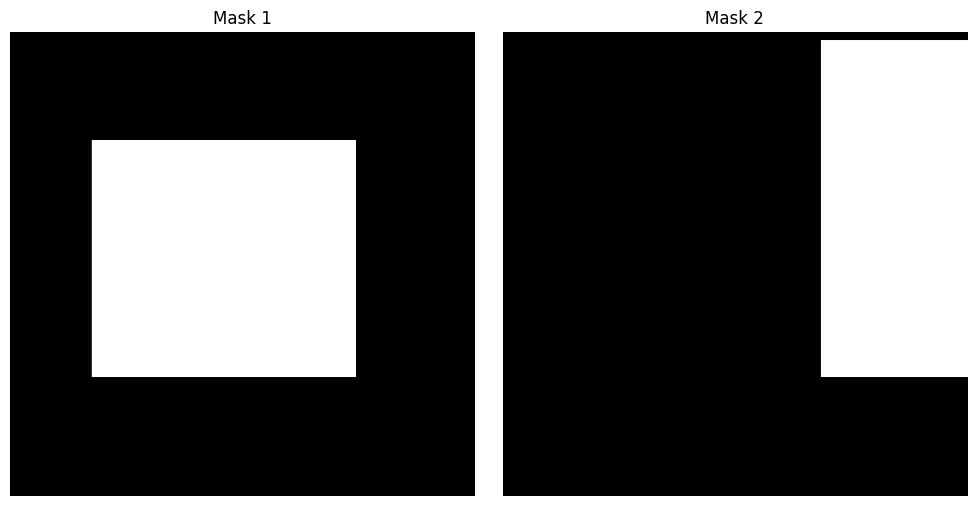

In [9]:
# initialize masks
mask1 = np.zeros(image_data.shape[:2], np.uint8)
mask2 = np.zeros(image_data.shape[:2], np.uint8)

# draw rectangles
cv2.rectangle(mask1, (90, 120), (380, 380), 255, -1)
cv2.rectangle(mask2, (350, 10), (635, 380), 255, -1)

# display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask1, cmap='gray')
plt.title("Mask 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask2, cmap='gray')
plt.title("Mask 2")
plt.axis("off")

plt.tight_layout()
plt.show()

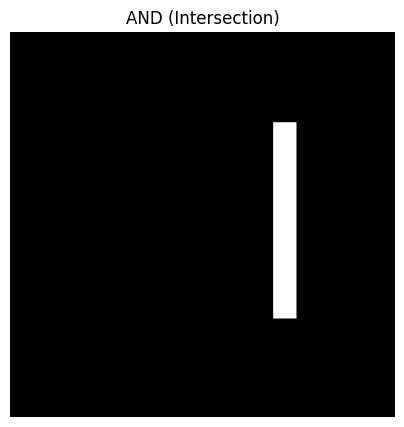

In [10]:
# Shows only where they intersect
And = cv2.bitwise_and(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(And, cmap='gray')
plt.title("AND (Intersection)")
plt.axis("off")
plt.show()

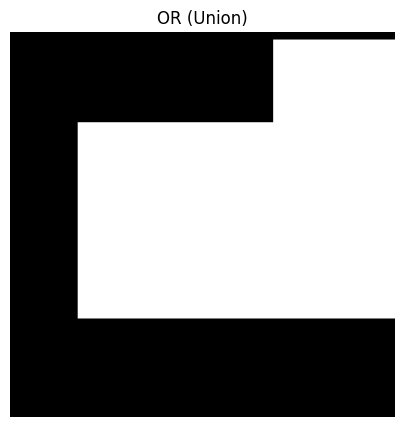

In [11]:
# Shows where either mask1 or mask2 is white
bitwiseOr = cv2.bitwise_or(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseOr, cmap='gray')
plt.title("OR (Union)")
plt.axis("off")
plt.show()

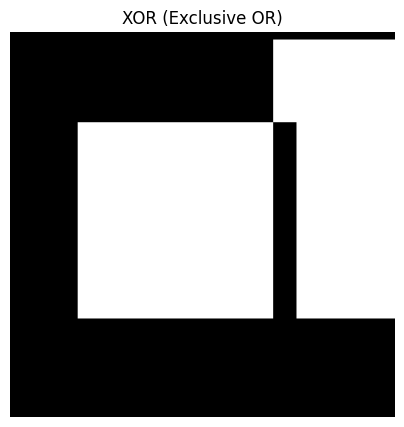

In [12]:
# Shows where either exists by itself (non-overlapping regions)
bitwiseXor = cv2.bitwise_xor(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseXor, cmap='gray')
plt.title("XOR (Exclusive OR)")
plt.axis("off")
plt.show()

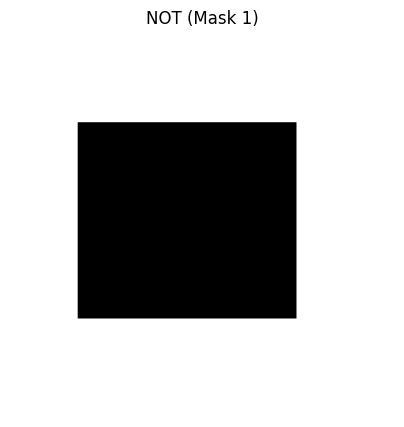

In [13]:
# Shows everything that isn't part of mask1
bitwiseNot_sq = cv2.bitwise_not(mask1)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseNot_sq, cmap='gray')
plt.title("NOT (Mask 1)")
plt.axis("off")
plt.show()

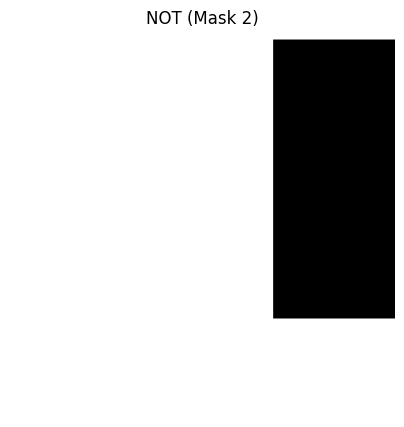

In [14]:
# Invert mask2
bitwiseNot_ell = cv2.bitwise_not(mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseNot_ell, cmap='gray')
plt.title("NOT (Mask 2)")
plt.axis("off")
plt.show()

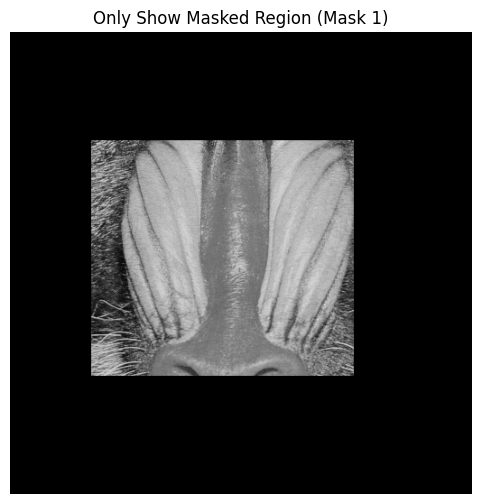

In [15]:
# Apply mask1 to the original image
puppy = cv2.bitwise_and(image_data, image_data, mask=mask1)

# Convert BGR to RGB for correct color display
puppy_rgb = cv2.cvtColor(puppy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(puppy_rgb)
plt.title("Only Show Masked Region (Mask 1)")
plt.axis("off")
plt.show()

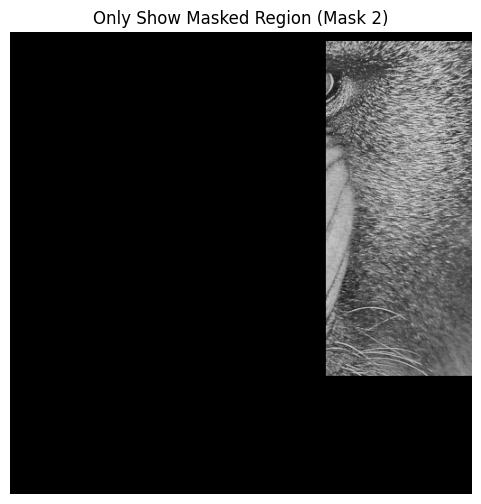

In [16]:
# Apply mask2 to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=mask2)

# Convert BGR to RGB for correct color display
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Only Show Masked Region (Mask 2)")
plt.axis("off")
plt.show()

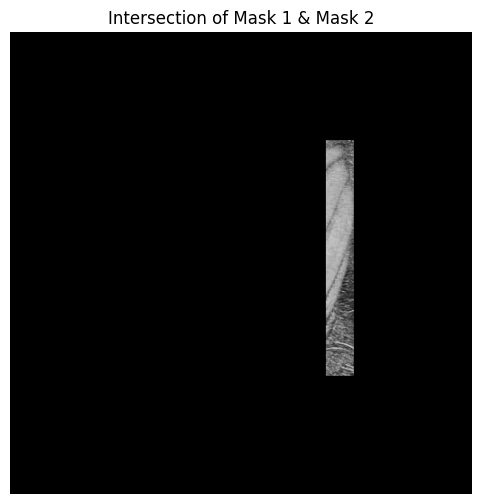

In [17]:
# Apply intersection mask (And) to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=And)

# Convert BGR to RGB
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Intersection of Mask 1 & Mask 2")
plt.axis("off")
plt.show()

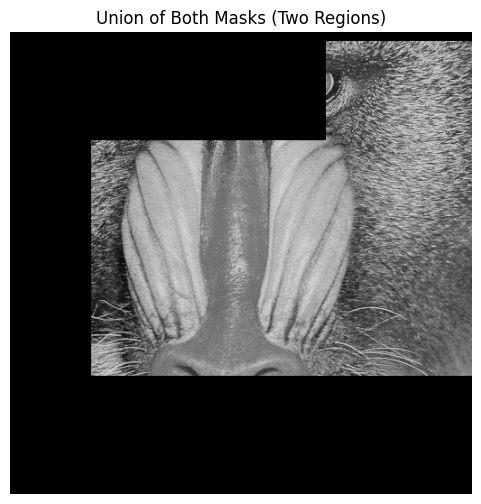

In [18]:
# Apply OR mask to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=bitwiseOr)

# Convert BGR → RGB for proper display
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Union of Both Masks (Two Regions)")
plt.axis("off")
plt.show()


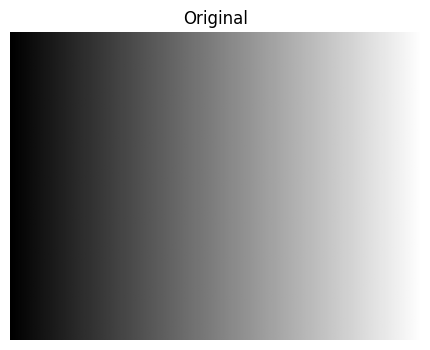

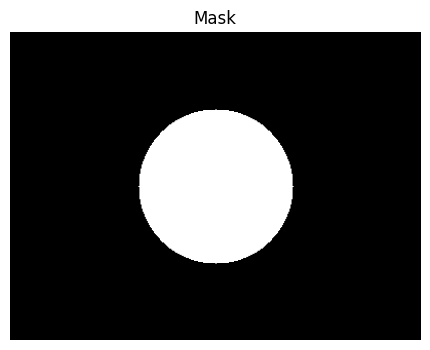

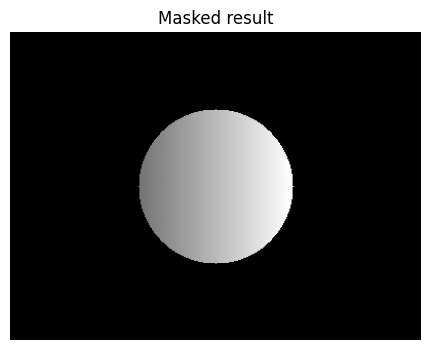

In [20]:
# TODO: Replace this synthetic image with your own if you like
img = np.tile(np.linspace(0,255,400, dtype=np.uint8), (300,1))

h, w = img.shape
mask = np.zeros((h,w), dtype=np.uint8)

# TODO: define center and radius, then draw the circle on mask
cx, cy = w//2, h//2
r = min(h,w)//4
cv2.circle(mask, (cx, cy), r, 255, -1)

# TODO: apply mask
masked = cv2.bitwise_and(img, img, mask=mask)

show(img, "Original", cmap="gray")
show(mask, "Mask", cmap="gray")
show(masked, "Masked result", cmap="gray")


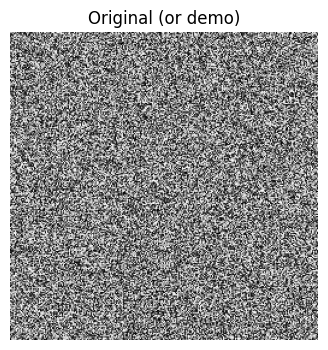

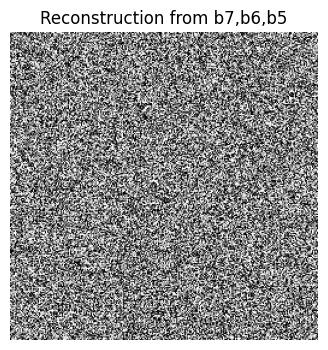

In [23]:
# TODO: load an image (grayscale)
img = cv2.imread("dataset/baboon.png", cv2.IMREAD_GRAYSCALE)

# Demo fallback (remove if using your own image):
img = (np.random.rand(256,256)*255).astype(np.uint8)

# Extract planes (planes[i] is bit i)
planes = [(img >> i) & 1 for i in range(8)]

# Reconstruct using planes 7,6,5
recon = np.zeros_like(img, dtype=np.uint8)
for i in [7,6,5]:
    recon = recon + (planes[i].astype(np.uint8) << i)

show(img, "Original (or demo)", cmap="gray")
show(recon, "Reconstruction from b7,b6,b5", cmap="gray")


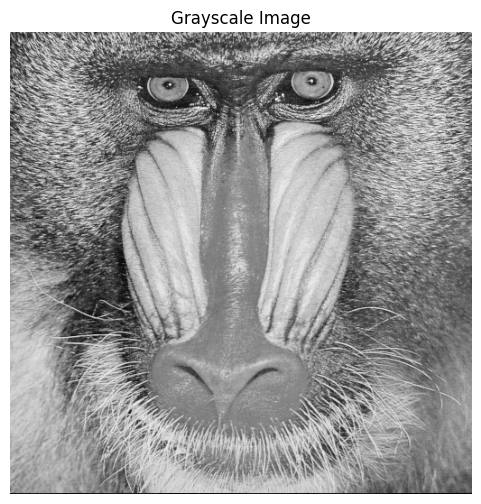

In [25]:
# Read image in grayscale
img = cv2.imread('dataset/baboon.png', 0)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Text(0, 0.5, 'Frequency')

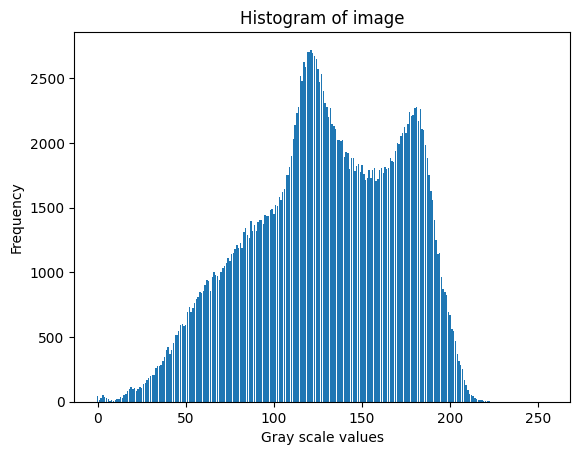

In [26]:
hist = cv2.calcHist(images=[img], channels=[0], mask=None, histSize=[256], ranges=[0, 255])

plt.bar(range(256), hist.ravel())
plt.title('Histogram of image')
plt.xlabel('Gray scale values')
plt.ylabel('Frequency')

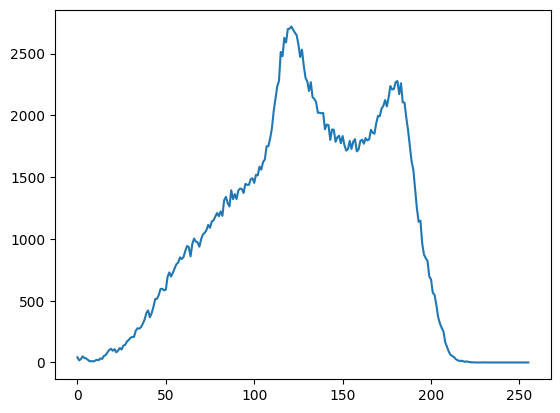

In [27]:
# Another method
hist,bins = np.histogram(img.ravel(),256,[0,256])
plt.plot(hist)

In [30]:
# Let's read two other images
high = cv2.imread('dataset/hist_highkey.jpg')
low = cv2.imread('dataset/hist_lowkey.jpg')

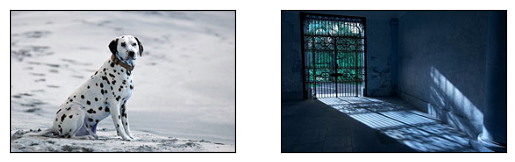

In [31]:
# show images
plt.subplot(121), plt.imshow(high)
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(low)
plt.grid(False), plt.xticks([]), plt.yticks([])
plt.show()

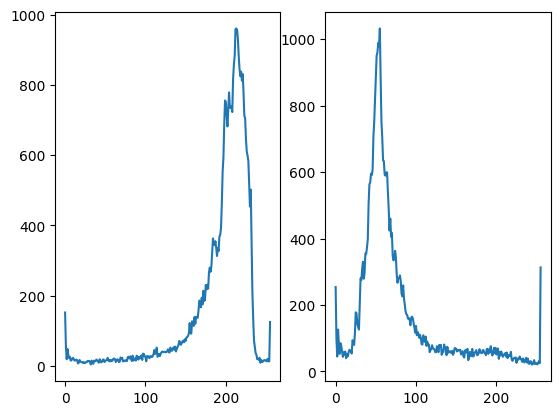

In [32]:
# Calculate histogram of both images for the last channel.
# Channels can differ from 0 to 2.
hist_high = cv2.calcHist([high],[2],None,[256],[0,256])
hist_low = cv2.calcHist([low],[2],None,[256],[0,256])

# Plot histograms
plt.subplot(121)
plt.plot(hist_high)

plt.subplot(122)
plt.plot(hist_low)

plt.show()

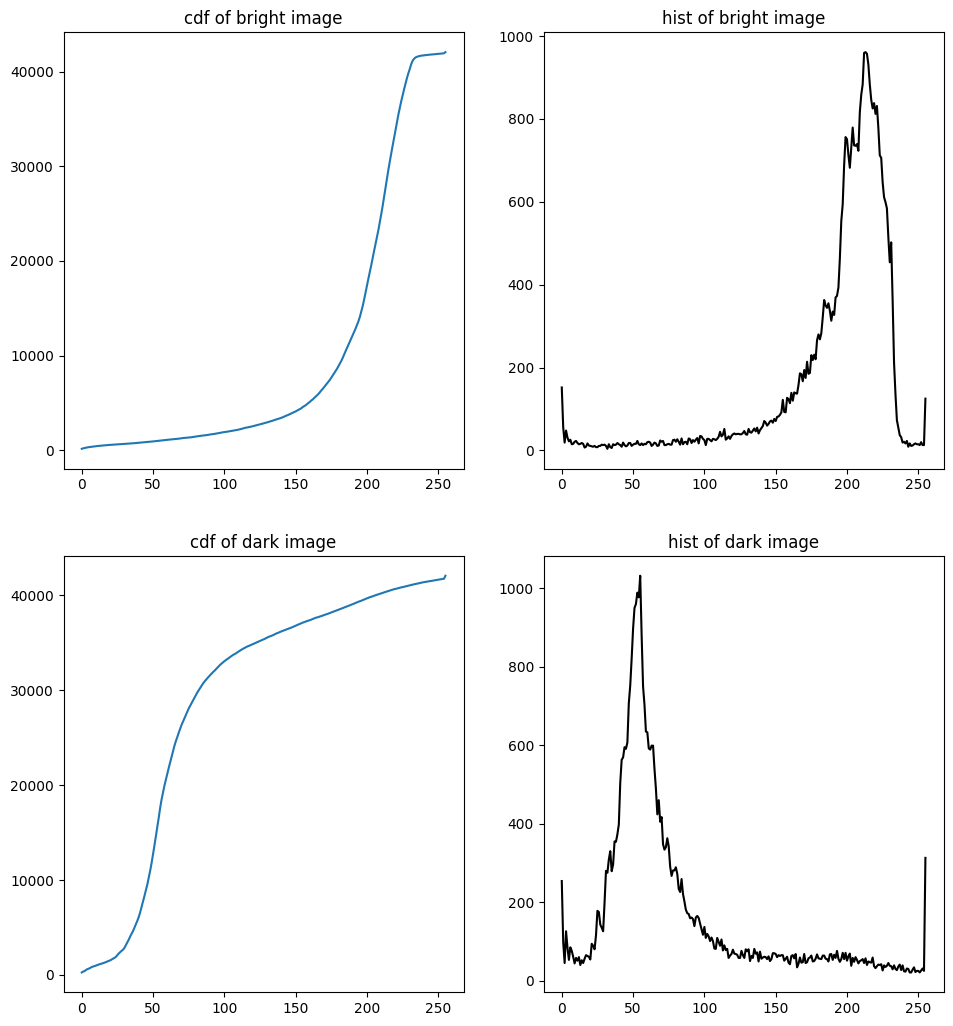

In [33]:
cdf_low = hist_low.cumsum()
cdf_high = hist_high.cumsum()

# plot cumulative histograms
plt.subplot(221), plt.plot(cdf_high), plt. title('cdf of bright image')
plt.subplot(222), plt.plot(hist_high, 'k'), plt. title('hist of bright image')

plt.subplot(223), plt.plot(cdf_low), plt. title('cdf of dark image')
plt.subplot(224), plt.plot(hist_low, 'k'), plt. title('hist of dark image')

# adjust the placement of subplots
plt.subplots_adjust(bottom=1, right=1.5, top=3)

plt.show()

In [34]:
low_gray = cv2.cvtColor(low, cv2.COLOR_BGR2GRAY)
high_gray = cv2.cvtColor(high, cv2.COLOR_BGR2GRAY)

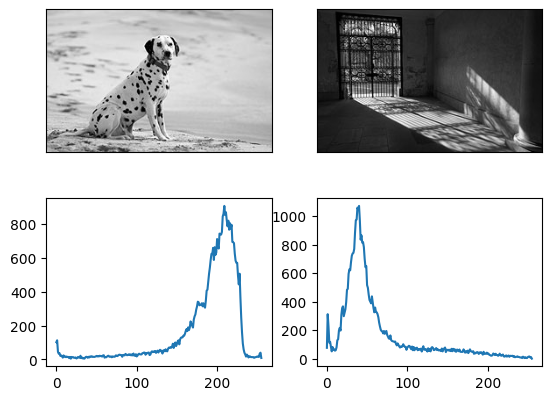

In [35]:
# show images and their histograms
plt.subplot(221), plt.imshow(high_gray, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])
plt.subplot(223), plt.plot(cv2.calcHist([high_gray],[0],None,[256],[0,256]))

plt.subplot(222), plt.imshow(low_gray, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])
plt.subplot(224), plt.plot(cv2.calcHist([low_gray],[0],None,[256],[0,256]))

plt.show()

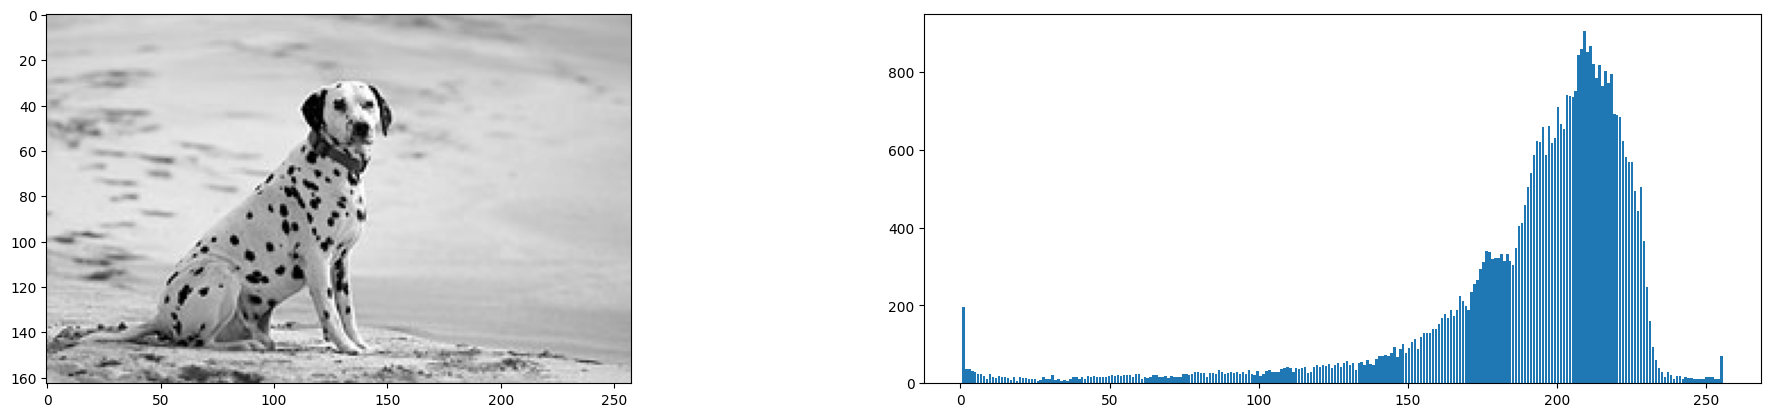

In [37]:
img = cv2.imread("dataset/hist_highkey.jpg", 0)
img_hist = np.histogram(img, bins=256)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.subplot(122), plt.bar(img_hist[1][1:], img_hist[0])
plt.subplots_adjust(right=3)
plt.show()

In [ ]:
t = 80
thresholded = img < t

plt.subplot(121)
plt.bar(img_hist[1][1:], img_hist[0])
plt.vlines(t, 0, np.amax(img_hist[0]), colors='r', linewidth=5)
plt.subplot(122)
plt.imshow(thresholded, cmap="gray")
plt.subplots_adjust(right=3)
plt.show()

print(thresholded[150])